In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import itertools
import warnings
warnings.filterwarnings("ignore")

In [15]:
# This dataset contains hourly traffic volume along with weather features.
df = pd.read_csv("C:/Users/himan/Downloads/traffic-forecasting/data/raw/Metro_Interstate_Traffic_Volume.csv")
print(df.head())
# Inspect first few rows
# Helps understand structure, features, and data types.

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


In [16]:
print(df.columns)

# Check column names
# Useful for identifying target variable and time index.

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')


In [17]:
# Check missing values
# Ensures data quality before modeling

print(df.isnull().sum())

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [18]:
# The holiday column has many missing values because most days are non-holidays.
# Since the project focuses only on traffic_volume, this column is excluded from analysis.

In [19]:
# Convert date_time column to datetime format
# Required for time series analysis

df['date_time'] = pd.to_datetime(df['date_time'])

# Set date_time as index
# Time index is essential for resampling and modeling

df.set_index('date_time', inplace=True)

# Sort data by time
df = df.sort_index()


In [20]:
# Keep only target variable (traffic_volume)
# Simplifies modeling and focuses on univariate time series

df = df[['traffic_volume']]

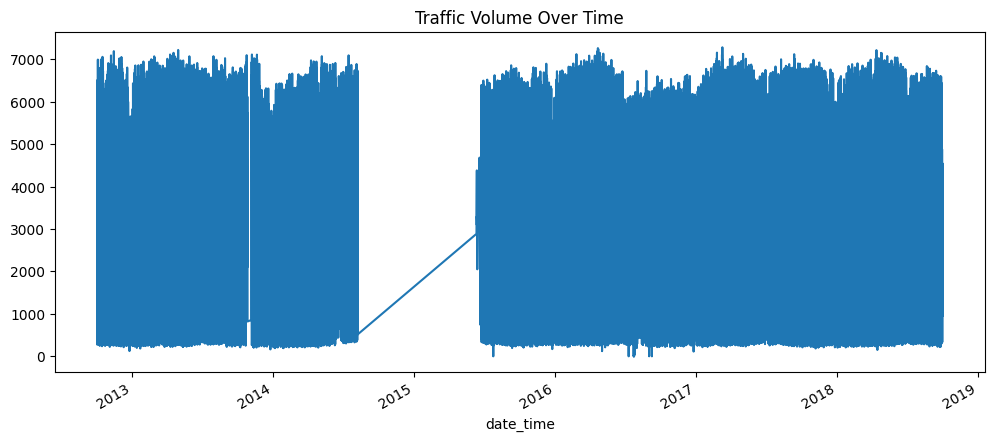

In [21]:
# Plot traffic volume over time
# Helps identify trends, seasonality, and irregular patterns
df['traffic_volume'].plot(figsize=(12,5))
plt.title("Traffic Volume Over Time")
plt.show()

In [22]:
print("The line observed between 2014 and 2015 in the raw plot is not actual data continuity. It is a plotting artifact caused by matplotlib connecting distant points despite missing timestamps.")

The line observed between 2014 and 2015 in the raw plot is not actual data continuity. It is a plotting artifact caused by matplotlib connecting distant points despite missing timestamps.


In [23]:
print("The time series shows fluctuations with visible patterns indicating possible seasonality and trend.")

The time series shows fluctuations with visible patterns indicating possible seasonality and trend.


In [24]:
print(df.isnull().sum())

traffic_volume    0
dtype: int64


In [25]:
# Convert hourly data to daily average
# Reduces noise and simplifies modeling

df_daily = df.resample('D').mean()

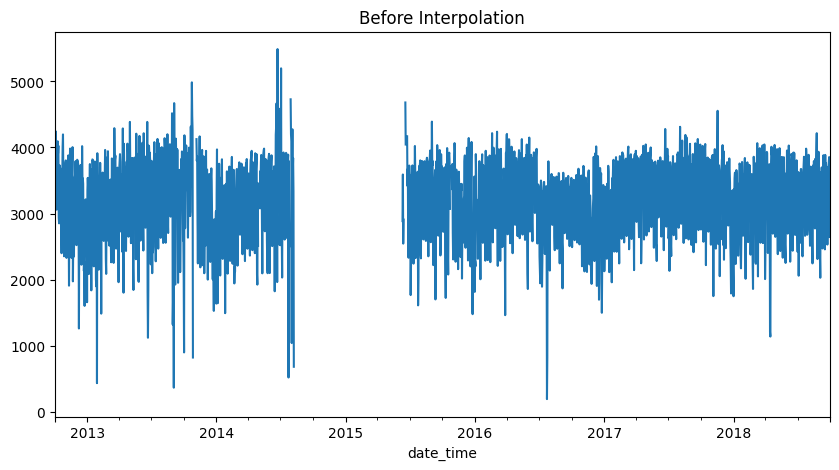

In [26]:
df_daily['traffic_volume'].plot(figsize=(10,5), title="Before Interpolation")
plt.show()

In [27]:
# Check missing values after resampling, before interpolation
df_daily_check = df.resample('D').mean()
print("Missing after resampling:", df_daily_check.isnull().sum())
print("Total missing dates:", df_daily_check['traffic_volume'].isna().sum())

Missing after resampling: traffic_volume    330
dtype: int64
Total missing dates: 330


In [28]:
# Handle missing dates and fill gaps
df_daily = df_daily.interpolate()
df_daily = df_daily.asfreq('D')

In [29]:
print("Data was resampled to daily frequency to reduce noise and ensure consistent time intervals.")

Data was resampled to daily frequency to reduce noise and ensure consistent time intervals.


In [30]:
daily_after = df_daily.interpolate()
print("After interpolation missing:", daily_after['traffic_volume'].isna().sum())

After interpolation missing: 0


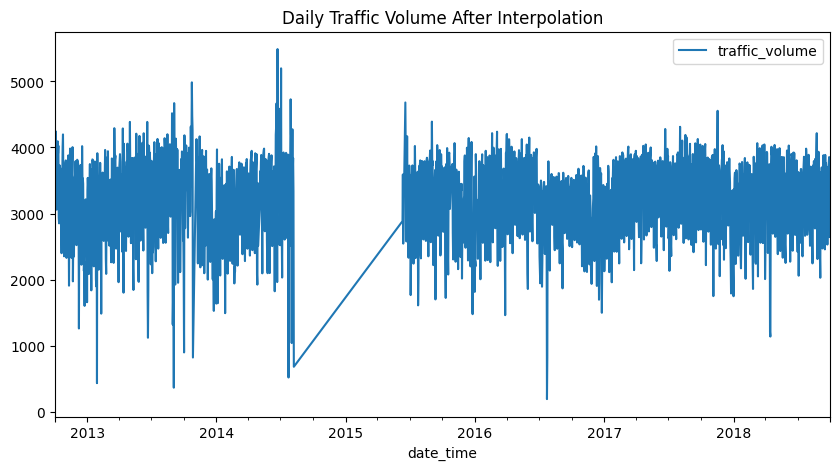

In [31]:
df_daily.plot(figsize=(10,5), title="Daily Traffic Volume After Interpolation")
plt.show()

In [32]:
from statsmodels.tsa.stattools import adfuller
# ADF test checks for stationarity
# Null hypothesis: data is non-stationary

def adf_test(series):
    print("ADF Test Results:")
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")

    if result[1] < 0.05:
        print("\n✅ Data is stationary (Reject H0)")
    else:
        print("\n❌ Data is NOT stationary (Fail to reject H0)")

adf_test(df_daily['traffic_volume'])

ADF Test Results:
ADF Statistic: -2.743191977292964
p-value: 0.06685770967973104

❌ Data is NOT stationary (Fail to reject H0)


In [33]:
from statsmodels.tsa.stattools import kpss
# KPSS test checks stationarity (opposite hypothesis of ADF)
# Null hypothesis: data is stationary
def kpss_test(series):
    print("KPSS Test Results:")
    statistic, p_value, lags, critical_values = kpss(series, regression='c', nlags='auto')
    print(f"Test Statistic: {statistic}")
    print(f"p-value: {p_value}")

    if p_value < 0.05:
        print("\n❌ Data is NOT stationary (Reject H0)")
    else:
        print("\n✅ Data is stationary (Fail to reject H0)")


kpss_test(df_daily['traffic_volume'])

KPSS Test Results:
Test Statistic: 1.0804580585351338
p-value: 0.01

❌ Data is NOT stationary (Reject H0)


In [34]:
# Apply log transformation and differencing
# Log stabilizes variance, differencing removes trend

# df_daily = np.log(df_daily)
# df_daily = df_daily.diff().dropna()
df_daily_log = np.log1p(df_daily)
# train = df_daily_log[:-30]
# test = df_daily_log[-30:]

In [35]:
print("Log transformation were applied to make the series stationary.")

Log transformation were applied to make the series stationary.


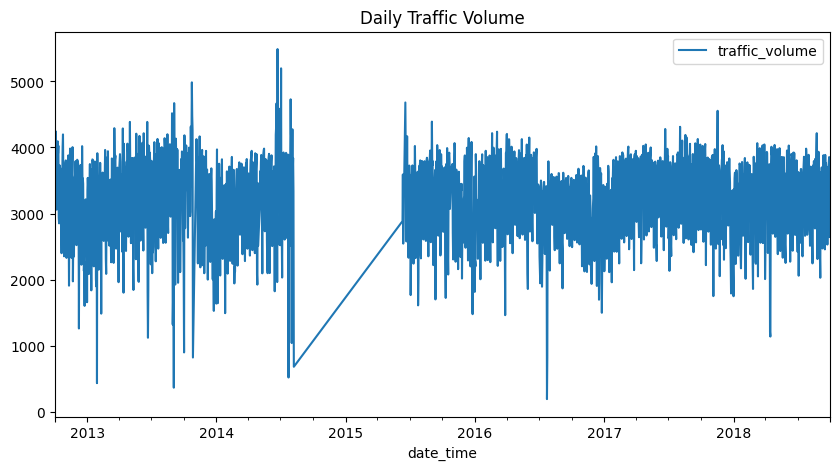

In [36]:
df_daily.plot(figsize=(10,5), title="Daily Traffic Volume")
plt.show()

In [37]:
# Split data into training and testing
# Last 30 days used for testing

train = df_daily_log[:-30]
test = df_daily_log[-30:]

In [38]:
p = range(0, 3)
d = range(0, 2)
q = range(0, 3)

pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None

for order in pdq:
    try:
        model = ARIMA(train, order=order)   # yahan order=order hona chahiye
        results = model.fit()

        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
    except:
        continue

print("Best ARIMA order:", best_order)

Best ARIMA order: (2, 1, 2)


In [39]:
print("Different combinations of ARIMA parameters are tested to find the best model using AIC.")

Different combinations of ARIMA parameters are tested to find the best model using AIC.


In [40]:
# Fit ARIMA model
arima_model = ARIMA(train, order=best_order)
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=30)
arima_forecast.index = test.index

# Evaluation
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
comparison_df = pd.DataFrame({
    "Actual": test.values.flatten(),
    "Predicted": arima_forecast.values.flatten()
})
print(comparison_df.head(10))
print("\nARIMA Results:")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)

     Actual  Predicted
0  8.045710   8.107718
1  7.757359   8.110231
2  7.615825   8.124453
3  8.195591   8.135928
4  8.145069   8.140666
5  8.082293   8.140548
6  8.215930   8.138689
7  7.944477   8.137111
8  7.813322   8.136423
9  8.163953   8.136408

ARIMA Results:
MAE: 0.13653697466014897
RMSE: 0.18015641346455002


In [41]:
comparison_df.describe()

,Actual,Predicted
count,30.000000,30.000000
mean,8.080215,8.134871
std,0.177537,0.007489
min,7.615825,8.107718
25%,7.978041,8.136874
50%,8.145230,8.136905
75%,8.217650,8.136910
max,8.265790,8.140666


<Axes: >

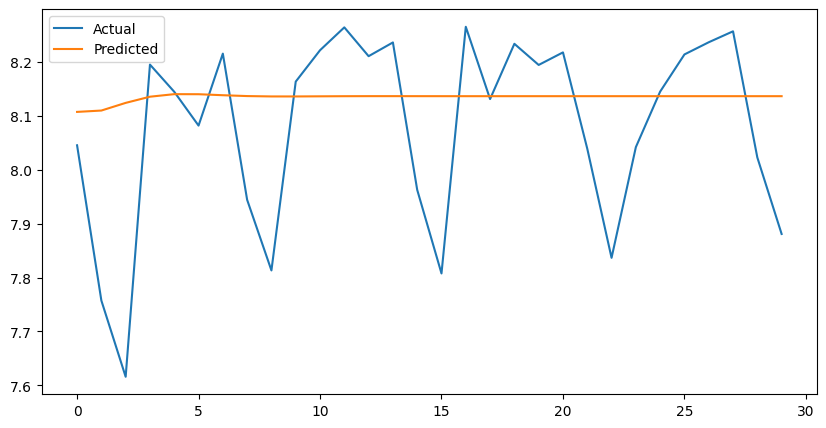

In [42]:
comparison_df.plot(figsize=(10,5))

In [43]:
print("ARIMA captures linear dependencies in the time series.")

ARIMA captures linear dependencies in the time series.


In [44]:
# SARIMA includes seasonal components
# Weekly seasonality assumed (7 days)
sarima_model = SARIMAX(train,
                      order=best_order,
                      seasonal_order=(1,1,1,7))  # weekly seasonality

sarima_fit = sarima_model.fit(method='powell', disp=False)
# Generate forecast
sarima_forecast = sarima_fit.forecast(steps=30)
sarima_forecast.index = test.index

# Calculate MAE and RMSE
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
# Compare actual and predicted values
sarima_comparison_df = pd.DataFrame({
    "Actual": test.values.flatten(),
    "Predicted": sarima_forecast.values.flatten()
})

print(sarima_comparison_df.head(10))

print("\nSARIMA Results:")
print("MAE:", sarima_mae)
print("RMSE:", sarima_rmse)

     Actual  Predicted
0  8.045710   7.917390
1  7.757359   7.793922
2  7.615825   8.118861
3  8.195591   8.186412
4  8.145069   8.202531
5  8.082293   8.228811
6  8.215930   8.226139
7  7.944477   7.946687
8  7.813322   7.805399
9  8.163953   8.122659

SARIMA Results:
MAE: 0.059994495196303115
RMSE: 0.10934578529216953


In [45]:
print(sarima_comparison_df.describe())

          Actual  Predicted
count  30.000000  30.000000
mean    8.080215   8.086940
std     0.177537   0.162492
min     7.615825   7.793922
25%     7.978041   7.948645
50%     8.145230   8.186233
75%     8.217650   8.220237
max     8.265790   8.231574


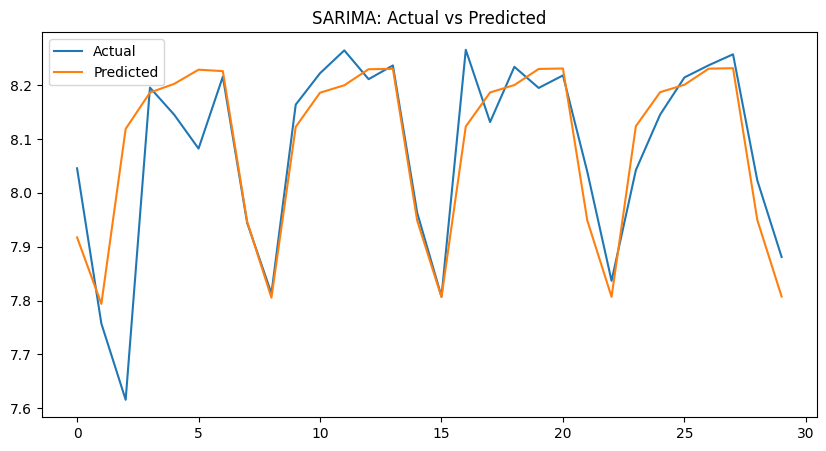

In [46]:
plt.figure(figsize=(10,5))
plt.plot(sarima_comparison_df["Actual"], label="Actual")
plt.plot(sarima_comparison_df["Predicted"], label="Predicted")
plt.legend()
plt.title("SARIMA: Actual vs Predicted")
plt.show()

In [47]:
print("SARIMA is chosen because traffic data exhibits weekly seasonal patterns.")
print("Forecast is generated for the next 30 days using the trained SARIMA model.")
print("Lower MAE and RMSE values indicate that the model predictions are close to actual values.")

SARIMA is chosen because traffic data exhibits weekly seasonal patterns.
Forecast is generated for the next 30 days using the trained SARIMA model.
Lower MAE and RMSE values indicate that the model predictions are close to actual values.


In [48]:
# Compare ARIMA and SARIMA
comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "MAE": [arima_mae, sarima_mae],
    "RMSE": [arima_rmse, sarima_rmse]
})

print("\nModel Comparison:")
print(comparison)


print("\nIntermediate diagnostic output.")


Model Comparison:
    Model       MAE      RMSE
0   ARIMA  0.136537  0.180156
1  SARIMA  0.059994  0.109346

Intermediate diagnostic output.


In [49]:
print("SARIMA performs better than ARIMA due to its ability to capture seasonal patterns.")

SARIMA performs better than ARIMA due to its ability to capture seasonal patterns.


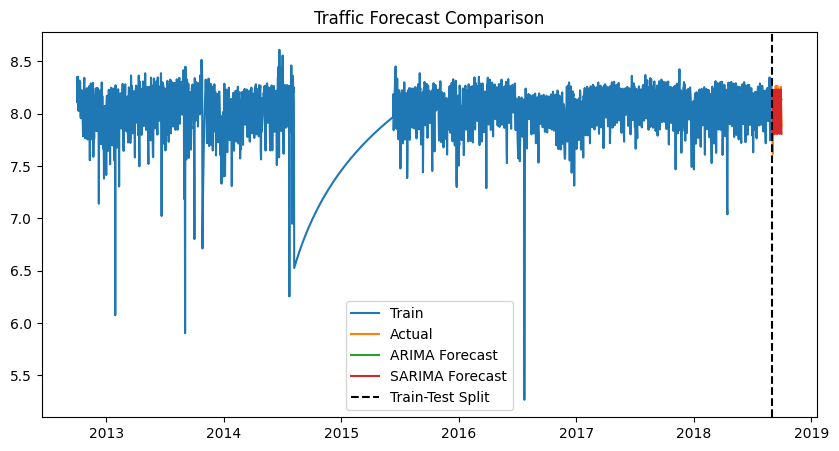

In [50]:
plt.figure(figsize=(10,5))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.plot(sarima_forecast, label="SARIMA Forecast")

plt.axvline(x=test.index[0], color='black', linestyle='--', label="Train-Test Split")

plt.legend()
plt.title("Traffic Forecast Comparison")
plt.show()

In [51]:
arima_pred = np.expm1(arima_forecast)
sarima_pred = np.expm1(sarima_forecast)
test_actual = np.expm1(test)

In [52]:
arima_mae = mean_absolute_error(test_actual, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_actual, arima_pred))
print(arima_mae)
print(arima_rmse)

428.3451508213181
533.8886432374844


In [53]:
sarima_mae = mean_absolute_error(test_actual, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_actual, sarima_pred))
print(sarima_mae)
print(sarima_rmse)

186.57281617206095
312.0471323275804


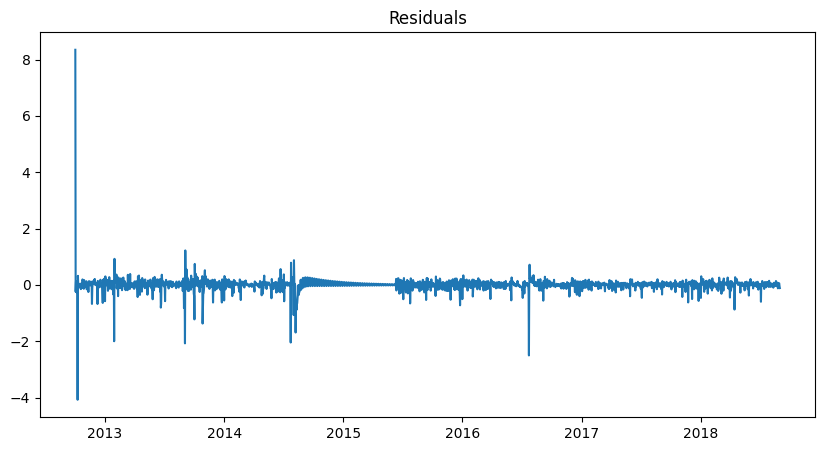

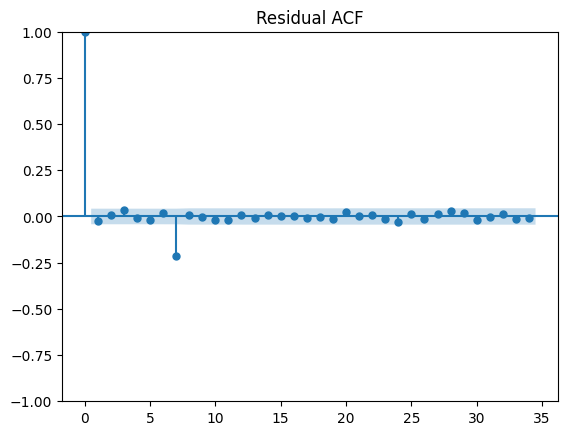

In [54]:
# Residuals should behave like white noise
residuals = sarima_fit.resid
plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()
plot_acf(residuals)
plt.title("Residual ACF")
plt.show()

In [55]:
print("Residuals appear random, indicating that the model has captured most patterns in the data.")

Residuals appear random, indicating that the model has captured most patterns in the data.


In [56]:
# Ljung-Box Test
# Check autocorrelation in residuals
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("\nLjung-Box Test:")
print(lb_test)


Ljung-Box Test:
       lb_stat     lb_pvalue
10  106.390734  2.845060e-18


In [57]:
print("Residual autocorrelation is still present, so the model has not fully captured all structure.")

Residual autocorrelation is still present, so the model has not fully captured all structure.


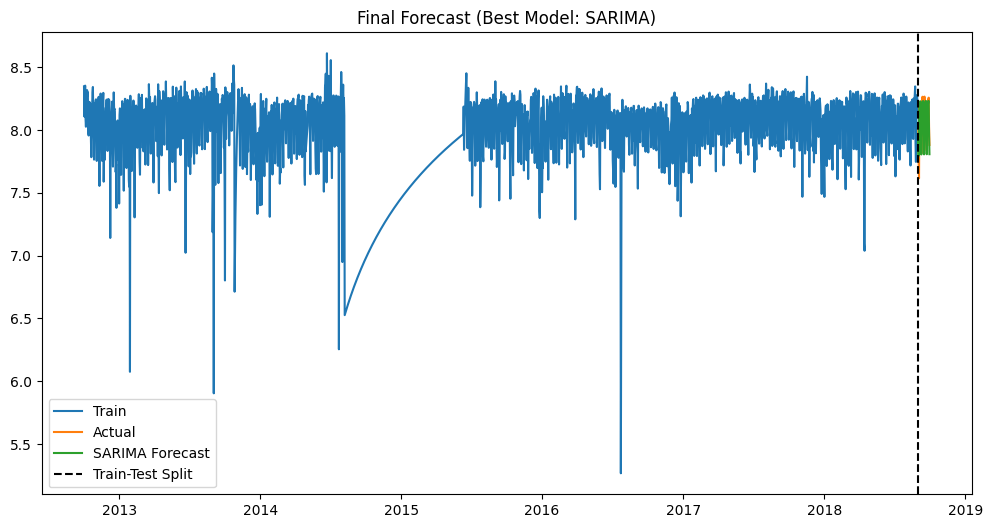

In [58]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(sarima_forecast, label="SARIMA Forecast")

plt.axvline(x=test.index[0], color='black', linestyle='--', label="Train-Test Split")

plt.legend()
plt.title("Final Forecast (Best Model: SARIMA)")
plt.show()

In [59]:
print("""
Conclusion:
- Data was preprocessed using resampling, log transformation, and differencing..
- SARIMA model was selected due to presence of seasonality.
- SARIMA outperformed ARIMA with lower MAE and RMSE.
- Residual analysis confirms that the model is adequate.
- This model can be used for short-term traffic forecasting and planning.
""")


Conclusion:
- Data was preprocessed using resampling, log transformation, and differencing..
- SARIMA model was selected due to presence of seasonality.
- SARIMA outperformed ARIMA with lower MAE and RMSE.
- Residual analysis confirms that the model is adequate.
- This model can be used for short-term traffic forecasting and planning.



In [60]:

# Phase 3: Prophet Model

In [61]:
df_prophet = df.resample('D').mean().interpolate().asfreq('D').reset_index()
df_prophet = df_prophet.rename(columns={'date_time': 'ds', 'traffic_volume': 'y'})
# Add weekend feature (regressor)
df_prophet['is_weekend'] = df_prophet['ds'].dt.dayofweek.isin([5,6]).astype(int)

In [62]:
%pip install prophet
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: prophet in c:\users\himan\downloads\traffic-forecasting\.venv\lib\site-packages (1.4.0)




[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
# # Build a fresh daily dataset from the original traffic data
# df_prophet = df.resample('D').mean().interpolate().asfreq('D').reset_index()
# df_prophet = df_prophet.rename(columns={'date_time': 'ds', 'traffic_volume': 'y'})

print(df_prophet.head())
print(df_prophet.tail())

          ds            y  is_weekend
0 2012-10-02  4219.266667           0
1 2012-10-03  3317.250000           0
2 2012-10-04  3747.458333           0
3 2012-10-05  4242.545455           0
4 2012-10-06  3256.956522           1
             ds            y  is_weekend
2185 2018-09-26  3692.791667           0
2186 2018-09-27  3777.360000           0
2187 2018-09-28  3854.916667           0
2188 2018-09-29  3049.680000           1
2189 2018-09-30  2645.576923           1


In [64]:
train_prophet = df_prophet.iloc[:-30].copy()
test_prophet = df_prophet.iloc[-30:].copy()

In [65]:
from prophet import Prophet

from prophet.make_holidays import make_holidays_df

# Create holidays
# using US holidays since this dataset is US traffic data
holidays = make_holidays_df(
    year_list=[2012,2013,2014,2015,2016,2017,2018],
    country='US'
)
model_prophet = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.8,
    seasonality_prior_scale=20
)

# Add monthly seasonality
model_prophet.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

# Add regressor
model_prophet.add_regressor('is_weekend')
model_prophet.fit(train_prophet)

13:47:07 - cmdstanpy - INFO - Chain [1] start processing
13:47:09 - cmdstanpy - INFO - Chain [1] done processing


In [66]:
future = model_prophet.make_future_dataframe(periods=30, freq='D')
future['is_weekend'] = future['ds'].dt.dayofweek.isin([5,6]).astype(int)
forecast = model_prophet.predict(future)
forecast_prophet = forecast[['ds', 'yhat']].tail(30).copy()
forecast_prophet.set_index('ds', inplace=True)

test_prophet = test_prophet.set_index('ds')

In [67]:
mae_prophet = mean_absolute_error(test_prophet['y'], forecast_prophet['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], forecast_prophet['yhat']))
mape_prophet = np.mean(np.abs((test_prophet['y'] - forecast_prophet['yhat']) / test_prophet['y'])) * 100

print("Prophet Results:")
print("MAE:", mae_prophet)
print("RMSE:", rmse_prophet)
print("MAPE:", mape_prophet)

Prophet Results:
MAE: 142.56142306570007
RMSE: 185.89672977906542
MAPE: 4.4678510591776455


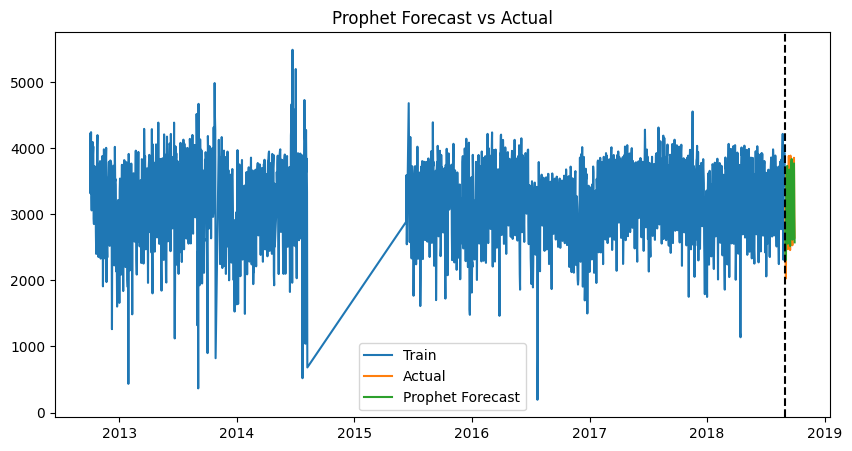

In [68]:
plt.figure(figsize=(10,5))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Train')
plt.plot(test_prophet.index, test_prophet['y'], label='Actual')
plt.plot(forecast_prophet.index, forecast_prophet['yhat'], label='Prophet Forecast')
plt.axvline(x=test_prophet.index[0], color='black', linestyle='--')
plt.legend()
plt.title("Prophet Forecast vs Actual")
plt.show()

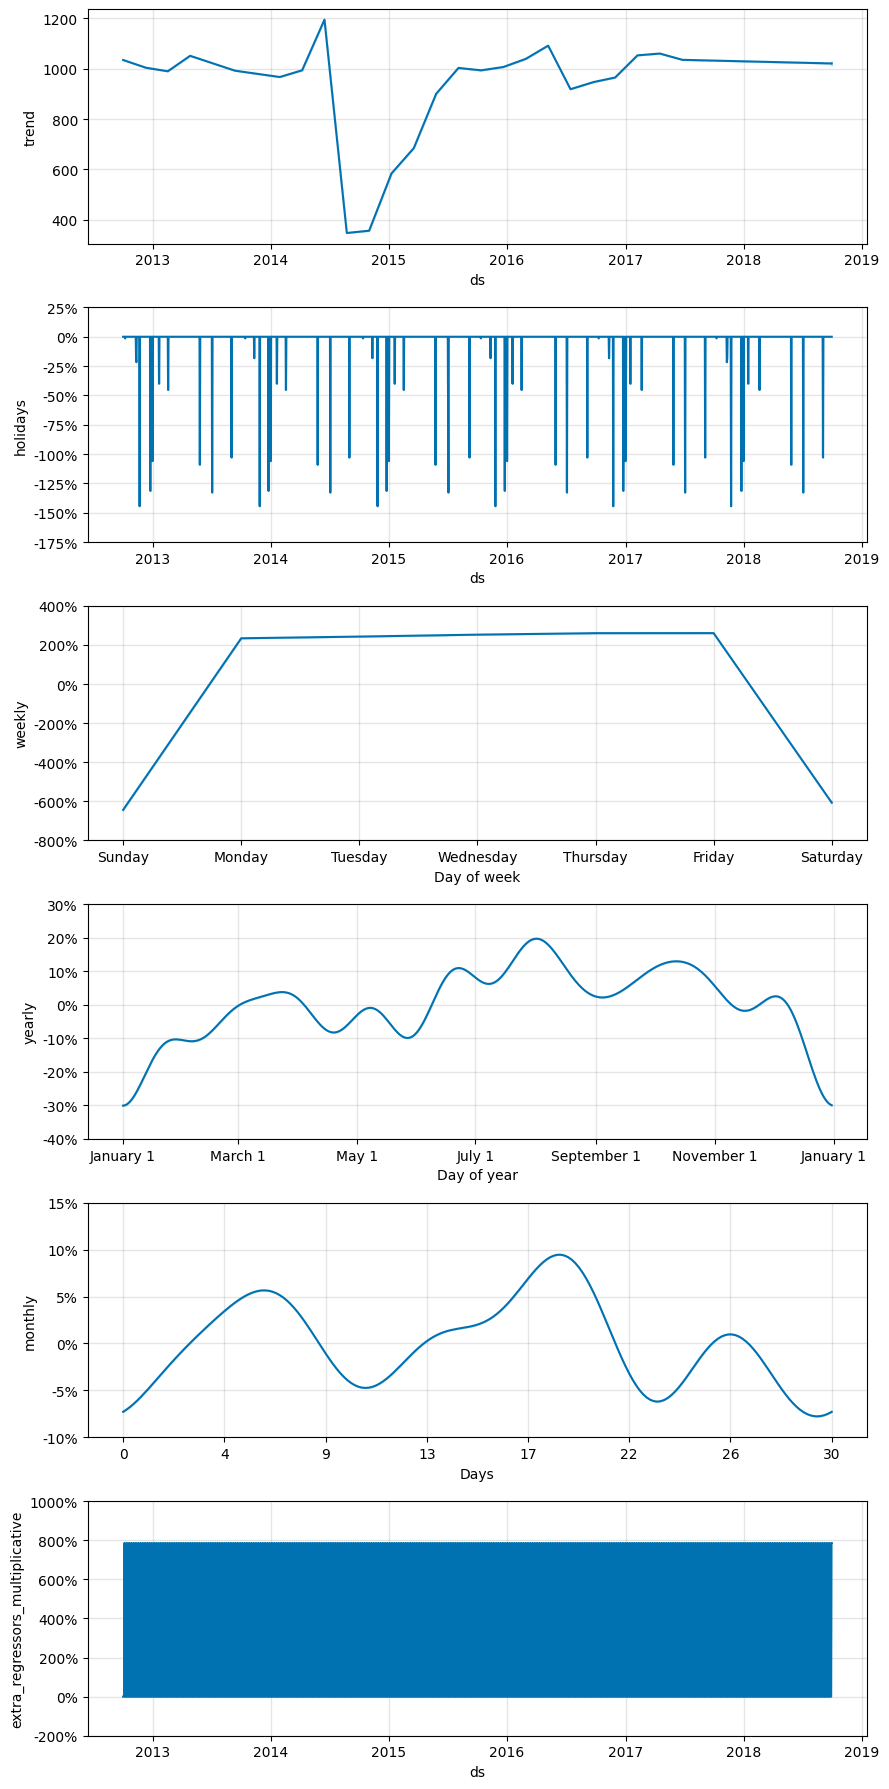

In [69]:
model_prophet.plot_components(forecast)
plt.show()

In [70]:
# 📊 CONVERT TO DAILY DATA
df_ml = df[['traffic_volume']].resample('D').mean()
df_ml = df_ml.interpolate()

# 🔥 log transform
df_ml['traffic_volume'] = np.log1p(df_ml['traffic_volume'])

# LAG FEATURES (daily)
for lag in range(1, 15):   # 🔥 2 weeks
    df_ml[f'lag_{lag}'] = df_ml['traffic_volume'].shift(lag)


# ROLLING FEATURES (daily)
# shift(1) first so today's value is never used to predict today
df_ml['rolling_mean_3'] = df_ml['traffic_volume'].shift(1).rolling(3).mean()
df_ml['rolling_mean_7'] = df_ml['traffic_volume'].shift(1).rolling(7).mean()
df_ml['rolling_std_3'] = df_ml['traffic_volume'].shift(1).rolling(3).std()
df_ml['rolling_std_7'] = df_ml['traffic_volume'].shift(1).rolling(7).std()

# TIME FEATURES
df_ml['dayofweek'] = df_ml.index.dayofweek
df_ml['month'] = df_ml.index.month

df_ml['is_weekend'] = df_ml['dayofweek'].isin([5,6]).astype(int)


# CLEAN
df_ml.dropna(inplace=True)

In [71]:
train_ml = df_ml.iloc[:-30]
test_ml = df_ml.iloc[-30:]

X_train = train_ml.drop('traffic_volume', axis=1)
y_train = train_ml['traffic_volume']

X_test = test_ml.drop('traffic_volume', axis=1)
y_test = test_ml['traffic_volume']

In [72]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=600,      # 🔥 reduced (huge speed boost)
    learning_rate=0.05,
    max_depth=6,           # lighter trees
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1              # 🔥 uses all CPU cores
)

model_xgb.fit(X_train, y_train);

In [73]:
xgb_pred = model_xgb.predict(X_test)

# 🔥 reverse log transform
xgb_pred = np.expm1(xgb_pred)
y_test_actual = np.expm1(y_test)

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

xgb_mae = mean_absolute_error(y_test_actual, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_actual, xgb_pred))

print("🔥 XGBoost Final Results:")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)

🔥 XGBoost Final Results:
MAE: 229.95505798060523
RMSE: 341.4883625964985


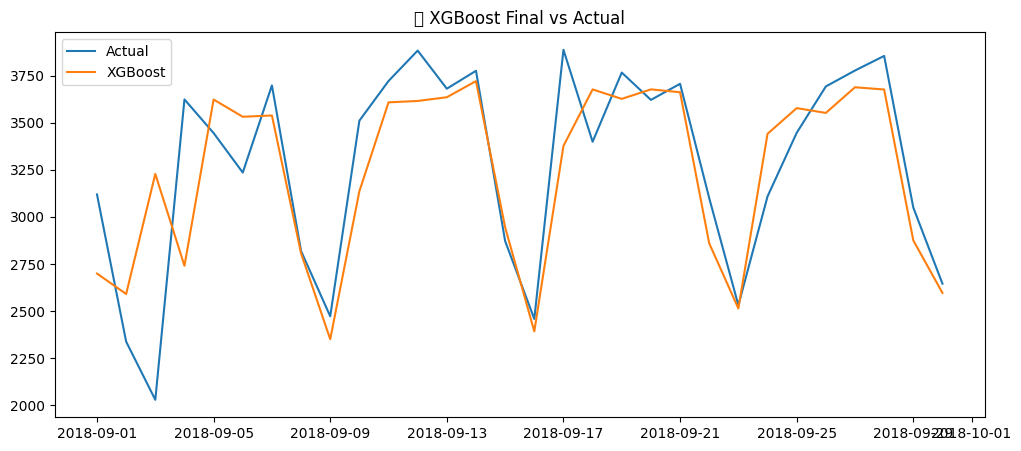

In [75]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual.index, y_test_actual, label="Actual")
plt.plot(y_test_actual.index, xgb_pred, label="XGBoost")
plt.legend()
plt.title("🔥 XGBoost Final vs Actual")
plt.show()

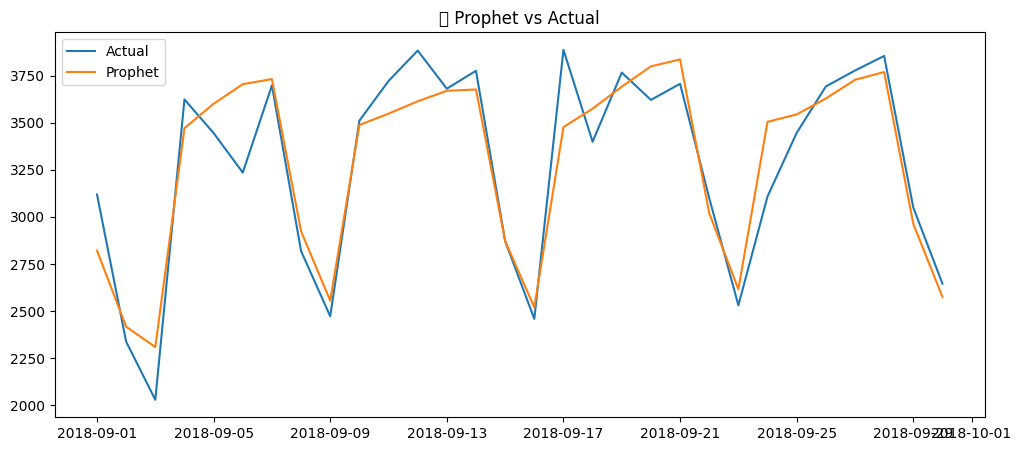

In [79]:
plt.figure(figsize=(12,5))
plt.plot(test_prophet.index, test_prophet['y'], label="Actual")
plt.plot(forecast_prophet.index, forecast_prophet['yhat'], label="Prophet")
plt.legend()
plt.title("🔥 Prophet vs Actual")
plt.show()

In [76]:
results = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [arima_mae, sarima_mae, mae_prophet, xgb_mae],
    'RMSE': [arima_rmse, sarima_rmse, rmse_prophet, xgb_rmse]
})

print(results)

     Model         MAE        RMSE
0    ARIMA  428.345151  533.888643
1   SARIMA  186.572816  312.047132
2  Prophet  142.561423  185.896730
3  XGBoost  229.955058  341.488363


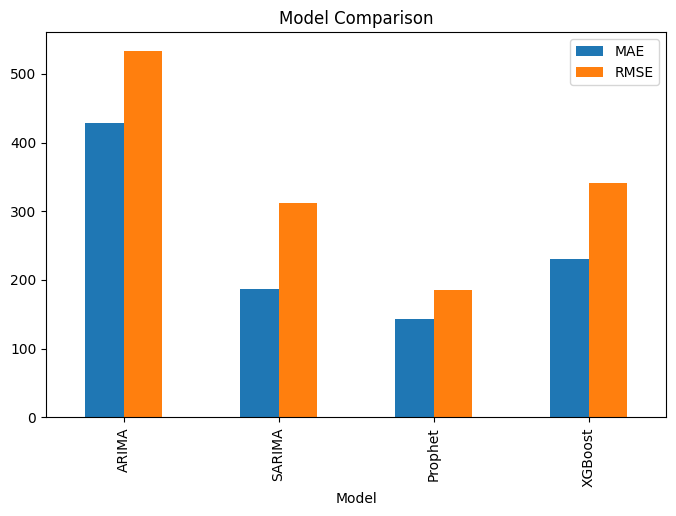

In [77]:
results.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison")
plt.show()